# NLP Lab 5 · EDA & Cleaning Template — Summarization

Colab-ready notebook for **abstractive summarization** datasets. Defaults to `xsum` (single-sentence summaries).
Includes length analysis, coverage proxy (token overlap), duplicates, and splits.


In [5]:

# @title Setup (it creates the title in Colab)
!pip -q install datasets matplotlib numpy pandas

import pandas as pd
import numpy as np
import os, re, unicodedata
import matplotlib.pyplot as plt
from datasets import load_dataset

plt.rcParams.update({"figure.figsize": (7,4)})
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1) Configuration & load

In [6]:
DATASET_NAME = "ShenLab/MentalChat16K"  #@param ['ShenLab/MentalChat16K']
# Load the dataset using the updated method
ds = load_dataset(DATASET_NAME)
print(ds)

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 16084
    })
})


## 2) Convert to pandas & inspect

In [7]:
def to_pandas(ds_dict, split):
    return ds_dict[split].to_pandas()

# xsum columns: document, summary
train_df = to_pandas(ds, "train")
print(train_df.head(2))
print(train_df.columns.tolist())

missing = train_df.isna().sum()
print("Missing values:\n", missing)

                                         instruction  \
0  You are a helpful mental health counselling as...   
1  You are a helpful mental health counselling as...   

                                               input  \
0  I've been struggling with my mental health for...   
1  I've been feeling overwhelmed with my caregivi...   

                                              output  
0  I understand that you've been dealing with a s...  
1  Your situation is complex, and it's important ...  
['instruction', 'input', 'output']
Missing values:
 instruction     0
input          27
output          0
dtype: int64


## 3) Cleaning helpers

In [10]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_TAG_RE = re.compile(r"<.*?>")

def basic_clean(text: str) -> str:
    """Limpieza básica: elimina URLs, HTML y espacios extra"""
    if not isinstance(text, str):
        return ""
    t = text.strip()
    t = re.sub(URL_RE, " ", t)
    t = re.sub(HTML_TAG_RE, " ", t)
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"\s+", " ", t)
    return t



def normalize_df(df: pd.DataFrame, doc_col: str, sum_col: str) -> pd.DataFrame:
    """Elimina nulos y aplica limpieza básica a las columnas indicadas"""
    df = df.dropna(subset=[doc_col, sum_col]).copy()
    df[doc_col] = df[doc_col].astype(str).apply(basic_clean)
    df[sum_col] = df[sum_col].astype(str).apply(basic_clean)
    return df


if {"instruction", "input", "output"}.issubset(train_df.columns):
    # Para el dataset ShenLab/MentalChat16K
    train_df = train_df.copy()
    train_df["source"] = (
        train_df["instruction"].fillna("").astype(str).str.strip() + " " +
        train_df["input"].fillna("").astype(str).str.strip()
    ).str.strip()

    DOC_COL = "source"   # texto de entrada (instrucción + input)
    SUM_COL = "output"   # texto objetivo (respuesta del asistente)

else:
    # Para otros datasets de resumen (como CNN/DailyMail)
    if "document" in train_df.columns and "summary" in train_df.columns:
        DOC_COL, SUM_COL = "document", "summary"
    elif "article" in train_df.columns and "highlights" in train_df.columns:
        DOC_COL, SUM_COL = "article", "highlights"
    else:
        raise ValueError(f"No reconozco las columnas en {train_df.columns.tolist()}")


clean_train_df = normalize_df(train_df, DOC_COL, SUM_COL)
clean_train_df.head(2)


,instruction,input,output,source
0,You are a helpful mental health counselling as...,I've been struggling with my mental health for...,I understand that you've been dealing with a s...,You are a helpful mental health counselling as...
1,You are a helpful mental health counselling as...,I've been feeling overwhelmed with my caregivi...,"Your situation is complex, and it's important ...",You are a helpful mental health counselling as...


## 4) Lengths & coverage proxy

In [11]:

def token_len(s: pd.Series):
    return s.astype(str).apply(lambda x: len(x.split())).tolist()

doc_lens = token_len(clean_train_df[DOC_COL])
sum_lens = token_len(clean_train_df[SUM_COL])

print("Avg doc len:", np.mean(doc_lens))
print("Avg summary len:", np.mean(sum_lens))

def coverage_ratio(doc: str, summ: str) -> float:
    d = set(str(doc).lower().split())
    s = set(str(summ).lower().split())
    if len(s)==0: return 0.0
    return len(d & s) / len(s)

cov = [coverage_ratio(d, s) for d, s in zip(clean_train_df[DOC_COL], clean_train_df[SUM_COL])]
print("Avg coverage ratio:", float(np.mean(cov)))


Avg doc len: 126.03419547376275
Avg summary len: 313.68894553593634
Avg coverage ratio: 0.1856538121800512


## 5) Plots & duplicates

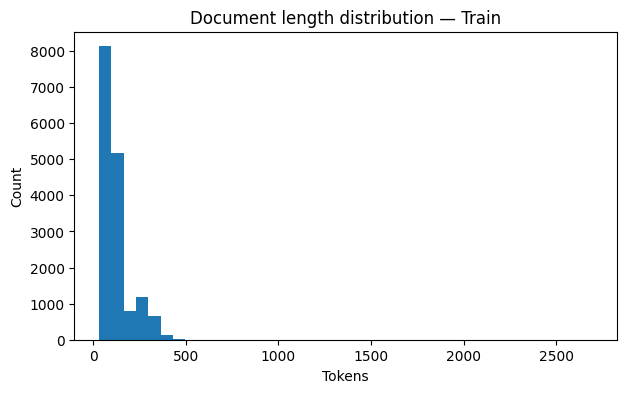

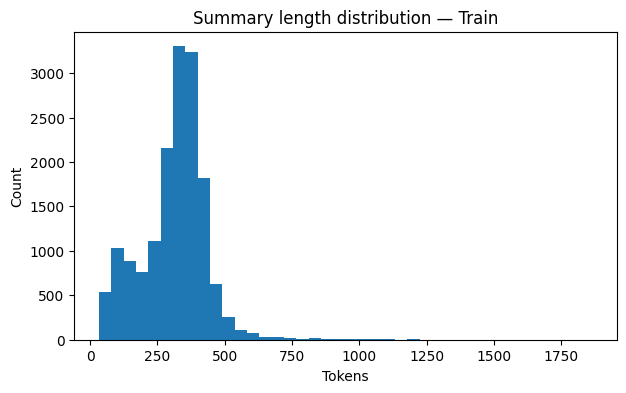

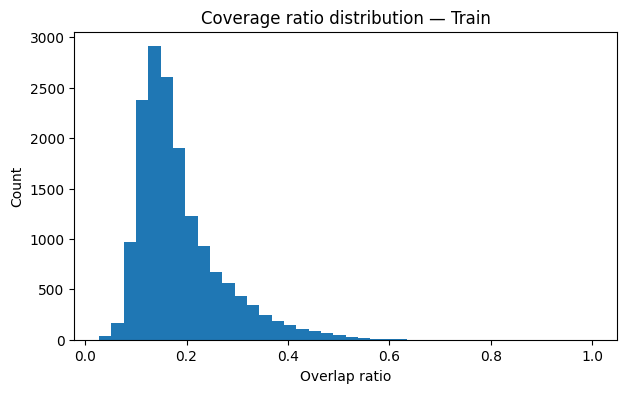

Duplicate (document+summary) rows: 79


In [12]:

def plot_hist(values, title, xlabel):
    plt.figure()
    plt.hist(values, bins=40)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

plot_hist(doc_lens, "Document length distribution — Train", "Tokens")
plot_hist(sum_lens, "Summary length distribution — Train", "Tokens")
plot_hist(cov, "Coverage ratio distribution — Train", "Overlap ratio")

dup_rows = clean_train_df.duplicated(subset=[DOC_COL, SUM_COL]).sum()
print("Duplicate (document+summary) rows:", dup_rows)


## 6) Train/Val/Test split (holdout) & save

In [13]:
# === Section 6: Memory-safe train/val/test split & JSONL export ===
import os, json, gc
import numpy as np
from sklearn.model_selection import train_test_split

# Uses existing variables from earlier sections:
# - clean_train_df (already cleaned)
# - DOC_COL, SUM_COL
# - RANDOM_SEED (fallback provided below if not defined)

try:
    RANDOM_SEED
except NameError:
    RANDOM_SEED = 42

# 1) Split by integer indices (tiny arrays, no DF copies)
idx_all = np.arange(len(clean_train_df), dtype=np.int64)
train_idx, temp_idx = train_test_split(
    idx_all, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=RANDOM_SEED, shuffle=True
)

print("Sizes:", len(train_idx), len(val_idx), len(test_idx))

# 2) Prepare output (streaming writes)
outdir = "summ_cleaned_splits"
os.makedirs(outdir, exist_ok=True)
paths = {
    "train": os.path.join(outdir, "train.jsonl"),
    "val":   os.path.join(outdir, "val.jsonl"),
    "test":  os.path.join(outdir, "test.jsonl"),
}

def write_split(indices, path):
    # Select only the needed columns lazily, iterate row-by-row.
    # itertuples avoids per-row Series allocations.
    with open(path, "w", encoding="utf-8") as f:
        for row in clean_train_df.loc[indices, [DOC_COL, SUM_COL]].itertuples(index=False, name=None):
            doc, summ = row
            f.write(json.dumps({DOC_COL: doc, SUM_COL: summ}, ensure_ascii=False))
            f.write("\n")

# 3) Write each split (free memory between steps)
write_split(train_idx, paths["train"]); gc.collect()
write_split(val_idx,   paths["val"]);   gc.collect()
write_split(test_idx,  paths["test"]);  gc.collect()

print("Saved to:", outdir)
# === End of Section 6 ===


Sizes: 11258 2413 2413
Saved to: summ_cleaned_splits
